In [0]:
customers_df = spark.read.format("csv") \
.option("header","true") \
.option("inferSchema","true") \
.load("/Volumes/final_cap/default/retail_analysis/customers.csv")

customers_df.show()

+-----------+-------------+---------+-----------+-------------+
|customer_id|customer_name|     city|      state|customer_type|
+-----------+-------------+---------+-----------+-------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|
|       C108|   Meera Nair|    Kochi|     Kerala|      Premium|
+-----------+-------------+---------+-----------+-------------+



In [0]:
products_df = spark.read.format("csv") \
.option("header","true") \
.option("inferSchema","true") \
.load("/Volumes/final_cap/default/retail_analysis/products.csv")

products_df.show()

+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronics|     25000|
|      P103|       Chair|  Furniture|      7000|
|      P104|       Table|  Furniture|     12000|
|      P105|       Shoes|    Fashion|      4500|
|      P106|       Watch|    Fashion|      8000|
|      P107|          TV|Electronics|     45000|
|      P108|         Bag|    Fashion|      3000|
+----------+------------+-----------+----------+



In [0]:
orders_df = spark.read.format("csv") \
.option("header","true") \
.option("inferSchema","true") \
.load("/Volumes/final_cap/default/retail_analysis/orders.csv")

orders_df.show()

+--------+-----------+----------+----------+--------+---------+
|order_id|customer_id|product_id|order_date|quantity|   status|
+--------+-----------+----------+----------+--------+---------+
|   O1001|       C101|      P101|2026-06-01|       1|Completed|
|   O1002|       C102|      P102|2026-06-01|       2|Completed|
|   O1003|       C103|      P103|2026-06-02|       3|  Pending|
|   O1004|       C104|      P104|2026-06-02|       2|Completed|
|   O1005|       C105|      P105|2026-06-03|       4|Cancelled|
|   O1006|       C106|      P106|2026-06-03|       1|Completed|
|   O1007|       C107|      P107|2026-06-04|       1|Completed|
|   O1008|       C108|      P108|2026-06-04|       5|Completed|
|   O1009|       C101|      P102|2026-06-05|       1|Completed|
|   O1010|       C104|      P101|2026-06-05|       1|Completed|
+--------+-----------+----------+----------+--------+---------+



In [0]:
preferences_df = spark.read \
    .option("multiline", "true") \
    .json("/Volumes/final_cap/default/retail_analysis/customer_preferences01.json")

preferences_df.show(truncate=False)

+-----------+----------------+-----------------+
|customer_id|loyalty         |preferred_channel|
+-----------+----------------+-----------------+
|C101       |{1200, Gold}    |Online           |
|C102       |{700, Silver}   |Store            |
|C104       |{2200, Platinum}|Online           |
|C108       |{1500, Gold}    |Mobile App       |
+-----------+----------------+-----------------+



In [0]:
customers_df.printSchema()
products_df.printSchema()
orders_df.printSchema()
preferences_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_customers")

In [0]:
products_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_products")

In [0]:
orders_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_orders")

In [0]:
preferences_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_preferences")

In [0]:
spark.sql("SHOW TABLES").show()

+--------+------------------+-----------+
|database|         tableName|isTemporary|
+--------+------------------+-----------+
| default|  bronze_customers|      false|
| default|     bronze_orders|      false|
| default|bronze_preferences|      false|
| default|   bronze_products|      false|
| default|  healthcare_delta|      false|
| default|    healthcare_sql|      false|
| default|managed_healthcare|      false|
| default|   patient_updates|      false|
+--------+------------------+-----------+



In [0]:
from pyspark.sql.functions import col, sum

customers_df.select([sum(col(c).isNull().cast("int")).alias(c) for c in customers_df.columns]).show()

+-----------+-------------+----+-----+-------------+
|customer_id|customer_name|city|state|customer_type|
+-----------+-------------+----+-----+-------------+
|          0|            0|   0|    0|            0|
+-----------+-------------+----+-----+-------------+



In [0]:
products_df.select([sum(col(c).isNull().cast("int")).alias(c) for c in products_df.columns]).show()

+----------+------------+--------+----------+
|product_id|product_name|category|unit_price|
+----------+------------+--------+----------+
|         0|           0|       0|         0|
+----------+------------+--------+----------+



In [0]:
orders_df.select([sum(col(c).isNull().cast("int")).alias(c) for c in orders_df.columns]).show()

+--------+-----------+----------+----------+--------+------+
|order_id|customer_id|product_id|order_date|quantity|status|
+--------+-----------+----------+----------+--------+------+
|       0|          0|         0|         0|       0|     0|
+--------+-----------+----------+----------+--------+------+



In [0]:
customers_df = customers_df.na.drop()
products_df = products_df.na.drop()
orders_df = orders_df.na.drop()

In [0]:
preferences_flat_df = preferences_df.select(
    "customer_id",
    "preferred_channel",
    col("loyalty.tier").alias("loyalty_tier"),
    col("loyalty.points").alias("loyalty_points")
)

preferences_flat_df.show()

+-----------+-----------------+------------+--------------+
|customer_id|preferred_channel|loyalty_tier|loyalty_points|
+-----------+-----------------+------------+--------------+
|       C101|           Online|        Gold|          1200|
|       C102|            Store|      Silver|           700|
|       C104|           Online|    Platinum|          2200|
|       C108|       Mobile App|        Gold|          1500|
+-----------+-----------------+------------+--------------+



In [0]:
customer_pref_df = customers_df.join(
    preferences_flat_df,
    "customer_id",
    "left"
)

customer_pref_df.show()

+-----------+-------------+---------+-----------+-------------+-----------------+------------+--------------+
|customer_id|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|
+-----------+-------------+---------+-----------+-------------+-----------------+------------+--------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|      Silver|           700|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|             NULL|        NULL|          NULL|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|           Online|    Platinum|          2200|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|             NULL|        NULL|          NULL|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|             NULL|        NULL|          NULL|
|       C1

In [0]:
orders_customers_df = orders_df.join(
    customer_pref_df,
    "customer_id",
    "inner"
)

orders_customers_df.show()

+-----------+--------+----------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+
|customer_id|order_id|product_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|
+-----------+--------+----------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+
|       C101|   O1009|      P102|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|
|       C102|   O1002|      P102|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|      Silver|           700|
|       C103|   O1003|      P103|2026-06-02|       3|  Pending|   Amit Kumar|   Mumbai|Maharashtra|      Regular|             NULL|        NULL|          NULL|
|       C104|   O1010|      P101|2026-06

In [0]:
final_df = orders_customers_df.join(
    products_df,
    "product_id",
    "inner"
)

final_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+
|      P102|       C101|   O1009|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Mobile|Electronics|     25000|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|      Silver|           700|      Mobile|Electronics|     25000|
|      P103|       C

In [0]:
final_df = final_df.withColumn(
    "revenue",
    col("quantity") * col("unit_price")
)

final_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|revenue|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+
|      P102|       C101|   O1009|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Mobile|Electronics|     25000|  25000|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|      Silver|           700|      Mobile|Electronics|

In [0]:
from pyspark.sql.functions import month

final_df = final_df.withColumn(
    "order_month",
    month("order_date")
)

In [0]:
from pyspark.sql.functions import when
final_df = final_df.withColumn(
    "customer_segment",
    when(col("customer_type")=="Premium","High Value")
    .otherwise("Standard Value")
)

final_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|      P102|       C101|   O1009|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Mobile|Electronics|     25000|  25000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Pri

In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_retail")

In [0]:
spark.sql("SHOW TABLES").show()

+--------+------------------+-----------+
|database|         tableName|isTemporary|
+--------+------------------+-----------+
| default|  bronze_customers|      false|
| default|     bronze_orders|      false|
| default|bronze_preferences|      false|
| default|   bronze_products|      false|
| default|  healthcare_delta|      false|
| default|    healthcare_sql|      false|
| default|managed_healthcare|      false|
| default|   patient_updates|      false|
| default|     silver_retail|      false|
+--------+------------------+-----------+



In [0]:
final_df.createOrReplaceTempView("retail_data")

customers_df.createOrReplaceTempView("customers")

products_df.createOrReplaceTempView("products")

orders_df.createOrReplaceTempView("orders")

In [0]:
spark.sql("""
SELECT SUM(revenue) AS total_revenue
FROM retail_data
""").show()

+-------------+
|total_revenue|
+-------------+
|       336000|
+-------------+



In [0]:
spark.sql("""
SELECT city,
       SUM(revenue) AS revenue
FROM retail_data
GROUP BY city
ORDER BY revenue DESC
""").show()

+---------+-------+
|     city|revenue|
+---------+-------+
|Hyderabad| 135000|
|    Delhi|  89000|
|Bangalore|  50000|
|   Mumbai|  21000|
|  Chennai|  18000|
|    Kochi|  15000|
|     Pune|   8000|
+---------+-------+



In [0]:
spark.sql("""
SELECT category,
       SUM(revenue) AS revenue
FROM retail_data
GROUP BY category
ORDER BY revenue DESC
""").show()

+-----------+-------+
|   category|revenue|
+-----------+-------+
|Electronics| 250000|
|  Furniture|  45000|
|    Fashion|  41000|
+-----------+-------+



In [0]:
spark.sql("""
SELECT customer_name,
       SUM(revenue) AS total_revenue
FROM retail_data
GROUP BY customer_name
ORDER BY total_revenue DESC
""").show()

+-------------+-------------+
|customer_name|total_revenue|
+-------------+-------------+
| Rahul Sharma|        90000|
|  Sneha Patel|        89000|
|  Priya Reddy|        50000|
|  Arjun Verma|        45000|
|   Amit Kumar|        21000|
|   Farhan Ali|        18000|
|   Meera Nair|        15000|
|   Neha Singh|         8000|
+-------------+-------------+



In [0]:
spark.sql("""
SELECT *
FROM retail_data
WHERE status='Completed'
""").show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|      P102|       C101|   O1009|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Mobile|Electronics|     25000|  25000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Pri

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import sum, dense_rank

In [0]:
product_revenue_df = final_df.groupBy(
    "product_id",
    "product_name"
).agg(
    sum("revenue").alias("total_revenue")
)

product_window = Window.orderBy(product_revenue_df["total_revenue"].desc())

product_rank_df = product_revenue_df.withColumn(
    "product_rank",
    dense_rank().over(product_window)
)

product_rank_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+------------+-------------+------------+
|product_id|product_name|total_revenue|product_rank|
+----------+------------+-------------+------------+
|      P101|      Laptop|       130000|           1|
|      P102|      Mobile|        75000|           2|
|      P107|          TV|        45000|           3|
|      P104|       Table|        24000|           4|
|      P103|       Chair|        21000|           5|
|      P105|       Shoes|        18000|           6|
|      P108|         Bag|        15000|           7|
|      P106|       Watch|         8000|           8|
+----------+------------+-------------+------------+



In [0]:
customer_revenue_df = final_df.groupBy(
    "customer_id",
    "customer_name"
).agg(
    sum("revenue").alias("total_revenue")
)

customer_window = Window.orderBy(
    customer_revenue_df["total_revenue"].desc()
)

customer_rank_df = customer_revenue_df.withColumn(
    "customer_rank",
    dense_rank().over(customer_window)
)

customer_rank_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+-------------+-------------+
|customer_id|customer_name|total_revenue|customer_rank|
+-----------+-------------+-------------+-------------+
|       C101| Rahul Sharma|        90000|            1|
|       C104|  Sneha Patel|        89000|            2|
|       C102|  Priya Reddy|        50000|            3|
|       C107|  Arjun Verma|        45000|            4|
|       C103|   Amit Kumar|        21000|            5|
|       C105|   Farhan Ali|        18000|            6|
|       C108|   Meera Nair|        15000|            7|
|       C106|   Neha Singh|         8000|            8|
+-----------+-------------+-------------+-------------+



In [0]:
top3_customers_df = customer_rank_df.filter(
    customer_rank_df.customer_rank <= 3
)

top3_customers_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+-------------+-------------+
|customer_id|customer_name|total_revenue|customer_rank|
+-----------+-------------+-------------+-------------+
|       C101| Rahul Sharma|        90000|            1|
|       C104|  Sneha Patel|        89000|            2|
|       C102|  Priya Reddy|        50000|            3|
+-----------+-------------+-------------+-------------+



In [0]:
category_product_df = final_df.groupBy(
    "category",
    "product_name"
).agg(
    sum("revenue").alias("total_revenue")
)

In [0]:
category_window = Window.partitionBy(
    "category"
).orderBy(
    category_product_df["total_revenue"].desc()
)

In [0]:
top_product_df = category_product_df.withColumn(
    "rank",
    dense_rank().over(category_window)
)

top_product_df.filter(
    top_product_df.rank == 1
).show()

+-----------+------------+-------------+----+
|   category|product_name|total_revenue|rank|
+-----------+------------+-------------+----+
|Electronics|      Laptop|       130000|   1|
|    Fashion|       Shoes|        18000|   1|
|  Furniture|       Table|        24000|   1|
+-----------+------------+-------------+----+



In [0]:
daily_revenue_df = final_df.groupBy(
    "order_date"
).agg(
    sum("revenue").alias("daily_revenue")
)
running_window = Window.orderBy("order_date")
from pyspark.sql.functions import sum

running_revenue_df = daily_revenue_df.withColumn(
    "running_revenue",
    sum("daily_revenue").over(running_window)
)

running_revenue_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-------------+---------------+
|order_date|daily_revenue|running_revenue|
+----------+-------------+---------------+
|2026-06-01|       115000|         115000|
|2026-06-02|        45000|         160000|
|2026-06-03|        26000|         186000|
|2026-06-04|        60000|         246000|
|2026-06-05|        90000|         336000|
+----------+-------------+---------------+



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.save("/FileStore/delta/retail_delta")

In [0]:
delta_df = spark.read.format("delta") \
.load("/FileStore/delta/retail_delta")

delta_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|      P102|       C101|   O1009|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Mobile|Electronics|     25000|  25000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Pri

In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("retail_delta_table")

In [0]:
spark.sql("""
CREATE TABLE retail_sql_table
USING DELTA
AS
SELECT * FROM retail_delta_table
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
%sql
DESCRIBE HISTORY retail_delta_table

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T09:24:11.000Z,144600303012599,azuser7231_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(2379182047046953),eaa2f2ab-9553-44ca-9f9d-70d8cbdcdeb3,0622-085908-4e0muuoo-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5836)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
spark.sql("DESCRIBE HISTORY retail_delta_table").show()

+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|version|          timestamp|         userId|            userName|           operation| operationParameters| job|          notebook|queryHistoryStatementId|           clusterId|readVersion|   isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|      0|2026-06-22 09:24:11|144600303012599|azuser7231_mml.lo...|CREATE OR REPLACE...|{isV1SaveAsTableO...|NULL|{2379182047046953}|   eaa2f2ab-9553-44c...|0622-085908-4

In [0]:
old_df = spark.read.format("delta") \
.option("versionAsOf",0) \
.table("retail_delta_table")

old_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|      P102|       C101|   O1009|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Mobile|Electronics|     25000|  25000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Pri

In [0]:
updated_data = [
("C101","Rahul Sharma","Hyderabad","Telangana","Premium"),
("C102","Priya Reddy","Chennai","Tamil Nadu","Regular")
]

columns = ["customer_id","customer_name","city","state","customer_type"]

updated_df = spark.createDataFrame(updated_data, columns)

In [0]:
customers_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("customer_delta")

In [0]:
from delta.tables import DeltaTable

delta_customer = DeltaTable.forName(spark,"customer_delta")

delta_customer.alias("target").merge(
    updated_df.alias("source"),
    "target.customer_id = source.customer_id"
).whenMatchedUpdateAll() \
 .whenNotMatchedInsertAll() \
 .execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
spark.sql("""
DESCRIBE HISTORY customer_delta
""").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
%sql
OPTIMIZE retail_delta_table

path,metrics
abfss://unity-catalog-storage@dbstoragexilgy5hegv2j6.dfs.core.windows.net/7405614861709757/__unitystorage/catalogs/1415a91c-1c51-403e-bfac-1f91383c9582/tables/b77ec3c7-49e1-4ece-b2eb-81b42fff1e23,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782120502259, 1782120502692, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
OPTIMIZE retail_delta_table
ZORDER BY(city)

path,metrics
abfss://unity-catalog-storage@dbstoragexilgy5hegv2j6.dfs.core.windows.net/7405614861709757/__unitystorage/catalogs/1415a91c-1c51-403e-bfac-1f91383c9582/tables/b77ec3c7-49e1-4ece-b2eb-81b42fff1e23,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 5836), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782120531824, 1782120532406, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
VACUUM retail_delta_table

path
abfss://unity-catalog-storage@dbstoragexilgy5hegv2j6.dfs.core.windows.net/7405614861709757/__unitystorage/catalogs/1415a91c-1c51-403e-bfac-1f91383c9582/tables/b77ec3c7-49e1-4ece-b2eb-81b42fff1e23


In [0]:
import matplotlib.pyplot as plt

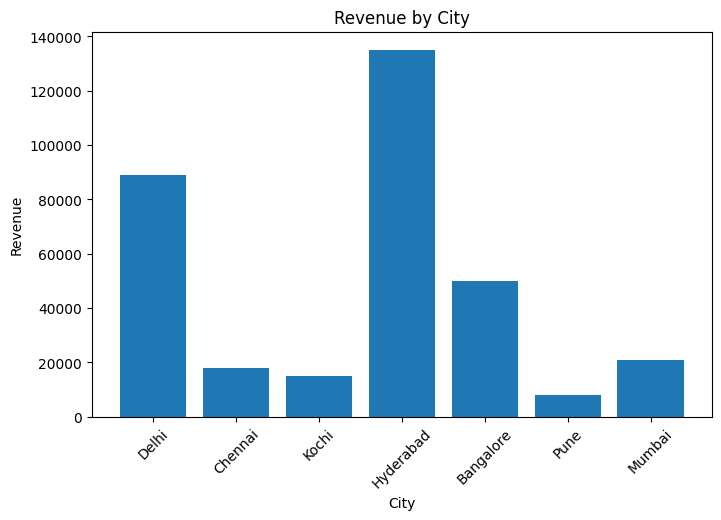

In [0]:
city_revenue_df = final_df.groupBy("city") \
    .sum("revenue") \
    .withColumnRenamed("sum(revenue)", "revenue")

city_pd = city_revenue_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_pd["city"], city_pd["revenue"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

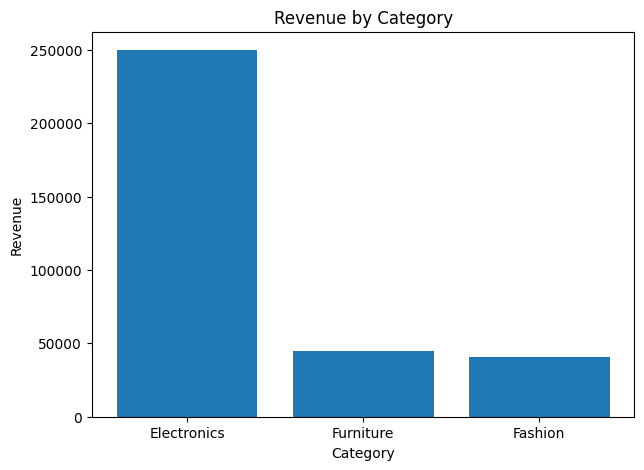

In [0]:
category_revenue_df = final_df.groupBy("category") \
    .sum("revenue") \
    .withColumnRenamed("sum(revenue)", "revenue")

category_pd = category_revenue_df.toPandas()

plt.figure(figsize=(7,5))
plt.bar(category_pd["category"], category_pd["revenue"])
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue by Category")
plt.show()

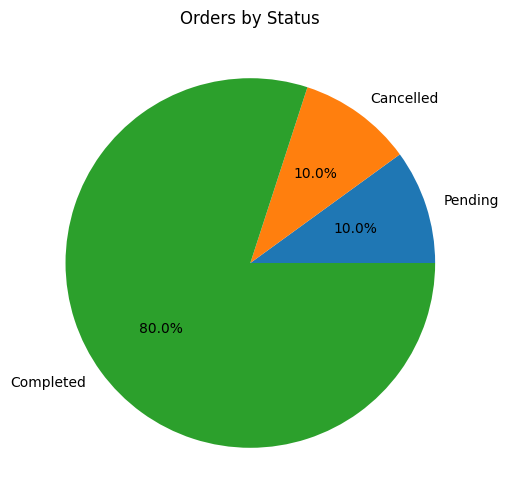

In [0]:
status_df = final_df.groupBy("status").count()

status_pd = status_df.toPandas()
plt.figure(figsize=(6,6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct='%1.1f%%'
)
plt.title("Orders by Status")
plt.show()

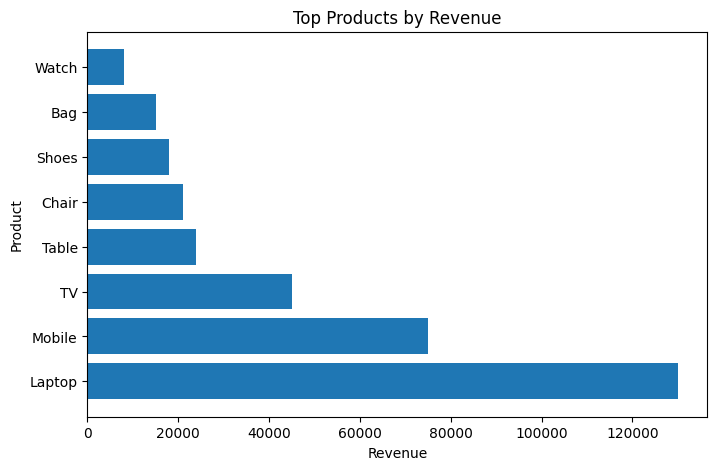

In [0]:
product_revenue_df = final_df.groupBy("product_name") \
    .sum("revenue") \
    .withColumnRenamed("sum(revenue)", "revenue")

product_pd = product_revenue_df.toPandas()

product_pd = product_pd.sort_values(
    by="revenue",
    ascending=False
)
plt.figure(figsize=(8,5))
plt.barh(
    product_pd["product_name"],
    product_pd["revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top Products by Revenue")
plt.show()

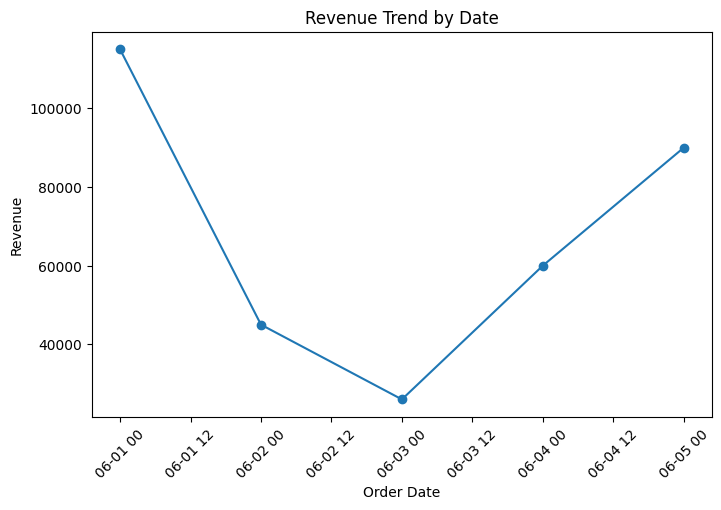

In [0]:
date_revenue_df = final_df.groupBy("order_date") \
    .sum("revenue") \
    .withColumnRenamed("sum(revenue)", "revenue")

date_pd = date_revenue_df.toPandas()

date_pd = date_pd.sort_values("order_date")
plt.figure(figsize=(8,5))
plt.plot(
    date_pd["order_date"],
    date_pd["revenue"],
    marker='o'
)

plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Date")
plt.xticks(rotation=45)
plt.show()

In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("managed_retail_table")

In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.save("/FileStore/external_retail")

In [0]:
final_df.createOrReplaceTempView("temp_retail_view")

In [0]:
spark.sql("""
SELECT customer_name,
       revenue
FROM temp_retail_view
""").show()

+-------------+-------+
|customer_name|revenue|
+-------------+-------+
| Rahul Sharma|  25000|
|  Priya Reddy|  50000|
|   Amit Kumar|  21000|
|  Sneha Patel|  65000|
|   Farhan Ali|  18000|
|   Neha Singh|   8000|
|  Arjun Verma|  45000|
|   Meera Nair|  15000|
| Rahul Sharma|  65000|
|  Sneha Patel|  24000|
+-------------+-------+



In [0]:
final_df.createOrReplaceGlobalTempView("global_retail_view")

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-8935882698724668>, line 1
----> 1 final_df.createOrReplaceGlobalTempView("global_retail_view")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:2129, in DataFrame.createOrReplaceGlobalTempView(self, name)
   2125 def createOrReplaceGlobalTempView(self, name: str) -> None:
   2126     command = plan.CreateView(
   2127         child=self._plan, name=name, is_global=True, replace=True
   2128     ).command(session=self._session.client)
-> 2129     _, _, ei = self._session.client.execute_command(command, self._plan.observations)
   2130     self._execution_info = ei

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, observations, extra_request_metadata)
   1536     req.user_context.user_id = s

In [0]:
spark.sql("SHOW TABLES").show()

+--------+--------------------+-----------+
|database|           tableName|isTemporary|
+--------+--------------------+-----------+
| default|    bronze_customers|      false|
| default|       bronze_orders|      false|
| default|  bronze_preferences|      false|
| default|     bronze_products|      false|
| default|      customer_delta|      false|
| default|    healthcare_delta|      false|
| default|      healthcare_sql|      false|
| default|  managed_healthcare|      false|
| default|managed_retail_table|      false|
| default|     patient_updates|      false|
| default|  retail_delta_table|      false|
| default|    retail_sql_table|      false|
| default|       silver_retail|      false|
|        |           customers|       true|
|        |              orders|       true|
|        |            products|       true|
|        |         retail_data|       true|
|        |    temp_retail_view|       true|
+--------+--------------------+-----------+

